In [15]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='keras')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import SGD
from tqdm.keras import TqdmCallback

I0000 00:00:1787824524.187948   16090 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [16]:
df = pd.read_csv('data/lorentz_set.csv').sample(frac=1, random_state=109) # shuffle DataFrame!

# Split train and test
x_train, x_test, y_train, y_test = train_test_split(df.x, df.y, train_size=0.7, random_state=109)

In [17]:
def plot_history(nn, title='', ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(nn.history.history['loss'], label='Training Loss')
    ax.plot(nn.history.history['val_loss'], label='Validation Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss (MSE)')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

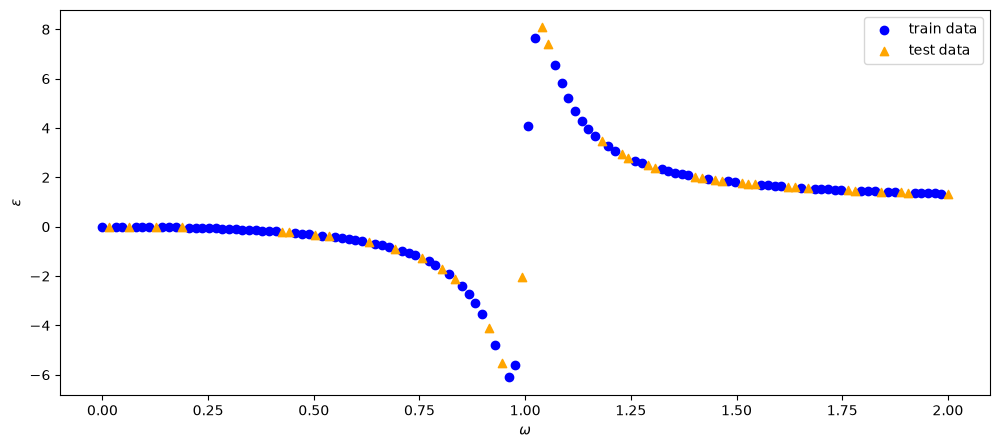

In [18]:
def plot_lorentz(df, test_idx, ax=None):
    if ax is None:
        ax = plt.gca()
    train_mask = np.ones(df.shape[0], dtype=bool)
    train_mask[test_idx] = False
    ax.scatter(df.x[train_mask],df.y[train_mask], c='b', label='train data')
    ax.scatter(df.x[~train_mask],df.y[~train_mask], c='orange', marker='^', label='test data')
    ax.set_xlabel(r'$\omega$')
    ax.set_ylabel(r'$\epsilon$')
    ax.legend()

plt.figure(figsize = (12,5))
plot_lorentz(df, x_test.index)

In [19]:
# Build the model
inputs = Input(shape=(1,))
x = Dense(50, activation='tanh')(inputs)
x = Dense(50, activation='tanh')(x)
outputs = Dense(1, activation='linear')(x)
NN1 = Model(inputs=inputs, outputs=outputs, name='NN1')
NN1.save_weights('NN1_init.weights.h5')
NN1.summary()

Model: "NN1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,701 (10.55 KB)

 Trainable params: 2,701 (10.55 KB)

 Non-trainable params: 0 (0.00 B)

0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

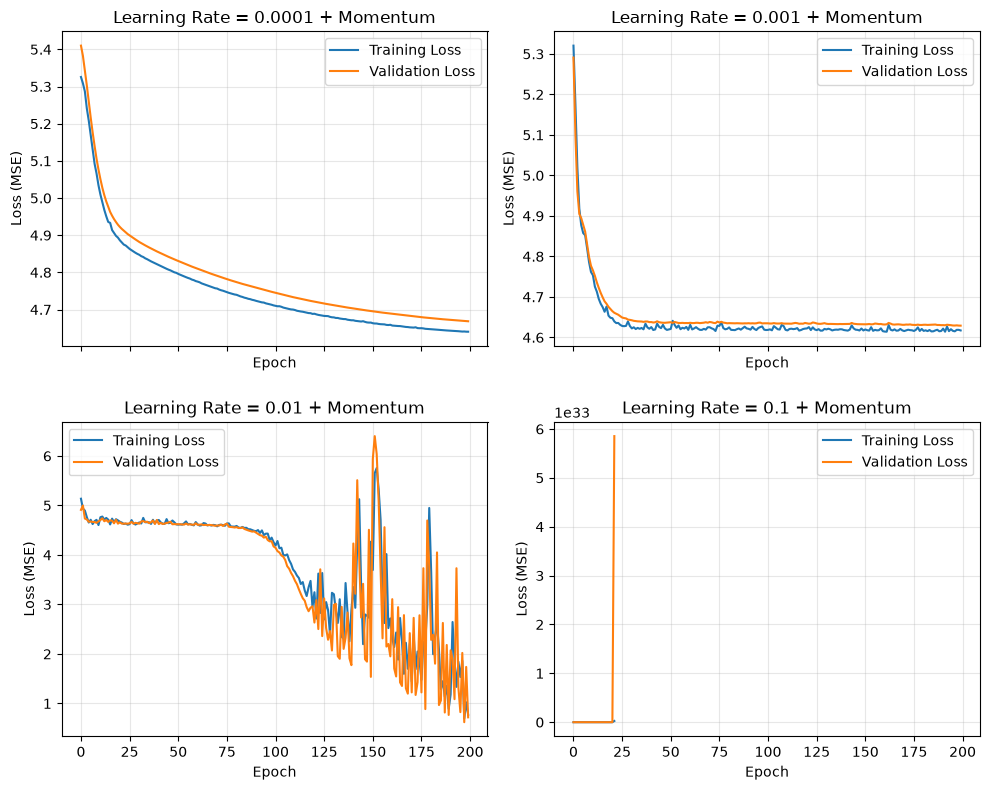

In [20]:
fig, axs = plt.subplots(2,2, figsize=(10,8), sharex=True)
axs = axs.flatten()
lrs = [1e-4, 1e-3, 1e-2, 0.1]
for ax, lr in zip(axs, lrs):
    NN1.load_weights('NN1_init.weights.h5')
    NN1.compile(optimizer=SGD(learning_rate=lr, momentum=0.9, nesterov=False),
                loss='mse')

    NN1.fit(x_train, y_train, 
            validation_data=(x_test, y_test),
            batch_size=32,
            epochs=200,
            verbose=0,
            callbacks=[TqdmCallback()])
    
    plot_history(NN1, title=f'Learning Rate = {lr} + Momentum', ax=ax)
plt.tight_layout()

What happened in the 4th example above? It looks like the combination of high learning rate and momentum caused a numerical overflow, likely from hitting very 'steep' parts of the loss surface. It is bad news once you get a nan in your computations. As you can see, the network weights have all become nan as well!

In [21]:
# Inspect strange behavior in 4th plot above - weights are NaN from lr=0.1 training
# Ouch! Numerical overflow did in our network
NN1.get_weights()

[array([[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
         nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
         nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
         nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]],
       dtype=float32),
 array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
       dtype=float32),
 array([[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]], shape=(50, 50), dtype=float32),
 array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,

The Keras optimizers have clipping aguments 'hidden in the *kwargs designation of their docstrings.

Here we use clipnorm prevent giant gradients (and thus giant weight updates) from causing problems.

In [22]:
### edTest(test_optimizer_config) ###
NN1.load_weights('NN1_init.weights.h5')

# Compile the neural network with an SGD optimizer with learning rate 0.1,
# momentum 0.9,  and norm clipping 0.1.
sgd_clipnorm = SGD(
        learning_rate=0.1,
        momentum=0.9,
        clipnorm=0.1
)


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

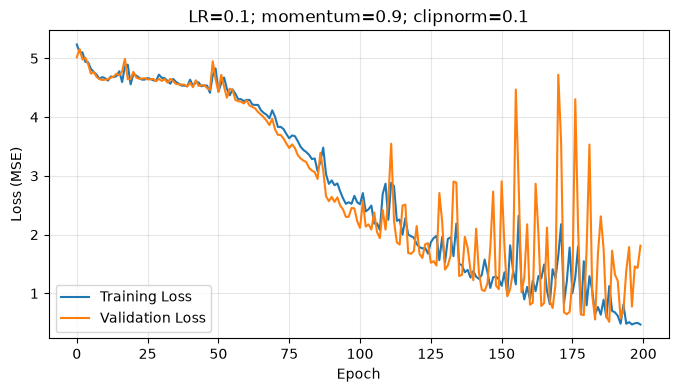

In [25]:
### edTest(test_model_compilation) ###
NN1.compile(optimizer=custom_sgd, loss='mse')

NN1.fit(x_train, y_train, 
        validation_data=(x_test, y_test),
        batch_size=32,
        epochs=200,
        verbose=0,
        callbacks=[TqdmCallback()])

plot_history(NN1, title=f'LR=0.1; momentum=0.9; clipnorm=0.1')